In [ ]:
# import sys
# !{sys.executable} -m pip install "pydantic<2"
# # needed <2 for ladybug tools

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, Path("./").absolute().as_posix())

from ladybug.epw import EPW
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.8f' % x)

from masterplanenergydemand.typology import Typology, BuildingType, Vintage, AnalysisPeriod
from masterplanenergydemand.mped import Masterplan

In [37]:
mped = Masterplan.from_excel(
    excel_file=r"C:\Users\tgerrish\Buro Happold\P055843 P-Dubai Expo City Masterplan - UNS - 05_Teams Files\Sustainability and climate\Energy\Copy of V2.2_240603_Masterplan Area Summary_per Plot.xlsx", 
    sheet_name="ECD_Baseline", 
    use_defaults=True
)

sd = mped.simulation_directory

masterplanenergydemand - INFO - Typology(Apartments) - Reloading energy consumption


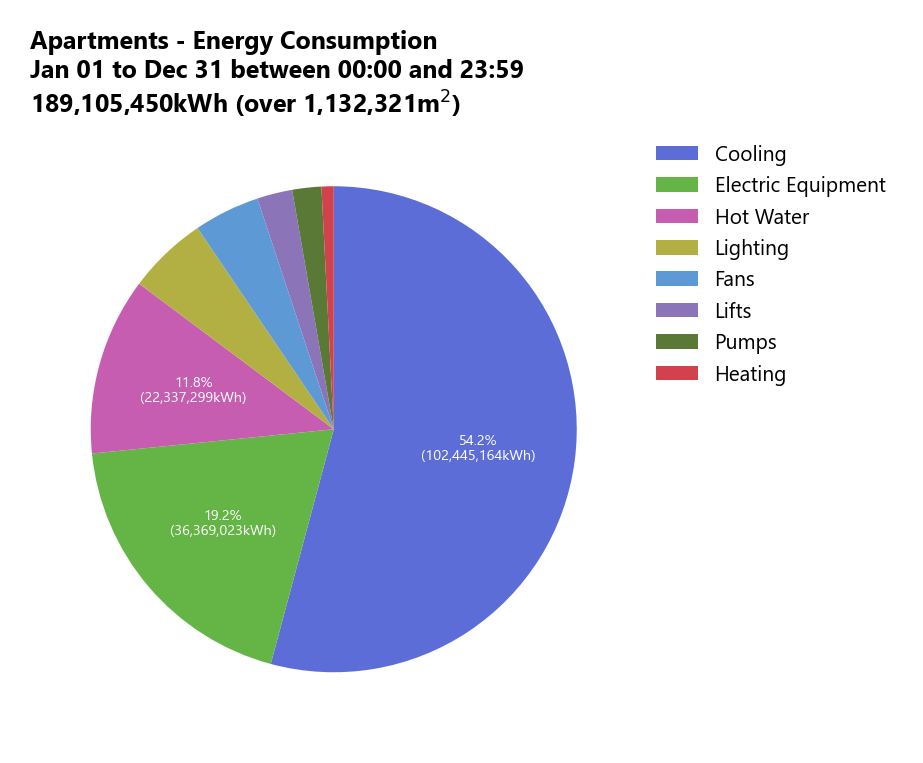

In [59]:
mped.typologies[0].plot_pie(directory=sd)
from masterplanenergydemand.util import get_color
# get_color("Heating")


masterplanenergydemand - INFO - Typology(Apartments) - Calculating cooling energy demand
masterplanenergydemand - INFO - Typology(Apartments) - Creating load balance data
masterplanenergydemand - INFO - Typology(Apartments) - Calculating heating energy demand
masterplanenergydemand - INFO - Typology(Apartments) - Reloading load balance data
masterplanenergydemand - INFO - Typology(Apartments) - Reloading annual EUI
masterplanenergydemand - WARNING - Typology(Apartments) - No heating demand found. Returning zeros.
masterplanenergydemand - INFO - Typology(Apartments) - Calculating lighting energy demand
masterplanenergydemand - INFO - Typology(Apartments) - Reloading load balance data
masterplanenergydemand - INFO - Typology(Apartments) - Reloading annual EUI
masterplanenergydemand - WARNING - Typology(Apartments) - No lighting demand found. Returning zeros.
masterplanenergydemand - INFO - Typology(Apartments) - Calculating electric equipment energy demand
masterplanenergydemand - INFO -

<Axes: title={'left': 'ECD_Baseline - Energy Consumption\nJan 01 to Dec 31 between 00:00 and 23:59\n254,407MWh'}>

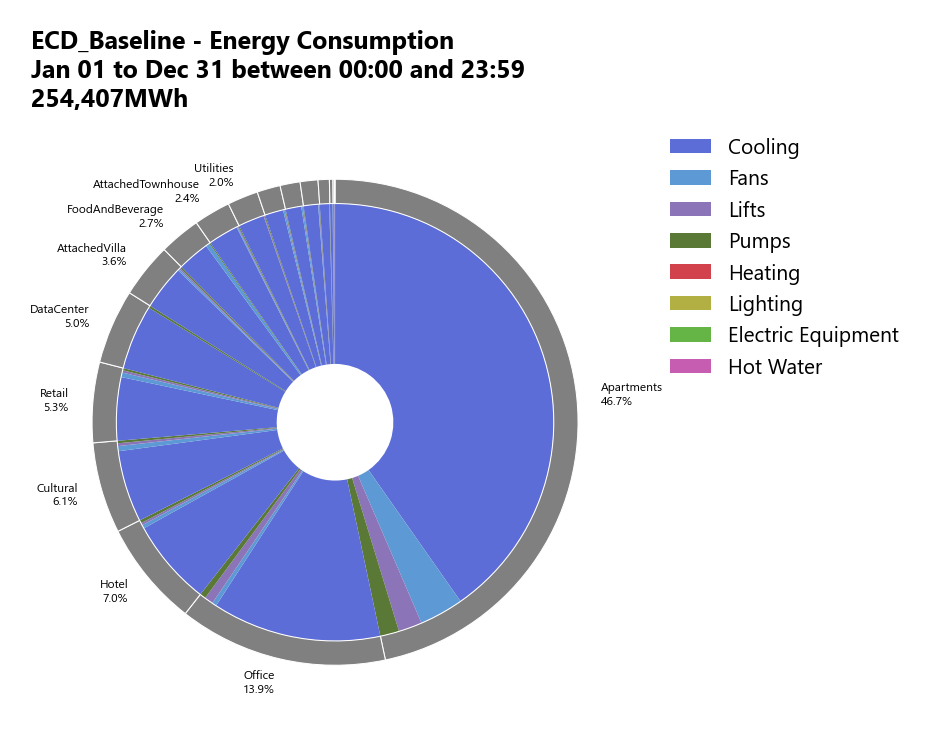

In [25]:
mped.plot_pie_distribution()

masterplanenergydemand - INFO - Masterplan(ECD_Baseline) - Plotting annual monthly energy consumption
masterplanenergydemand - INFO - Typology(Apartments) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(AttachedVilla) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(AttachedTownhouse) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(Retail) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(Office) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(FoodAndBeverage) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(LightIndustry) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(FuelStation) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(Hotel) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(Education) - Reloading energy consumption
masterplanenergydemand - INFO - Typology(Mosque) - Re

<Axes: title={'left': 'ECD_Baseline - Energy Consumption'}, ylabel='kWh'>

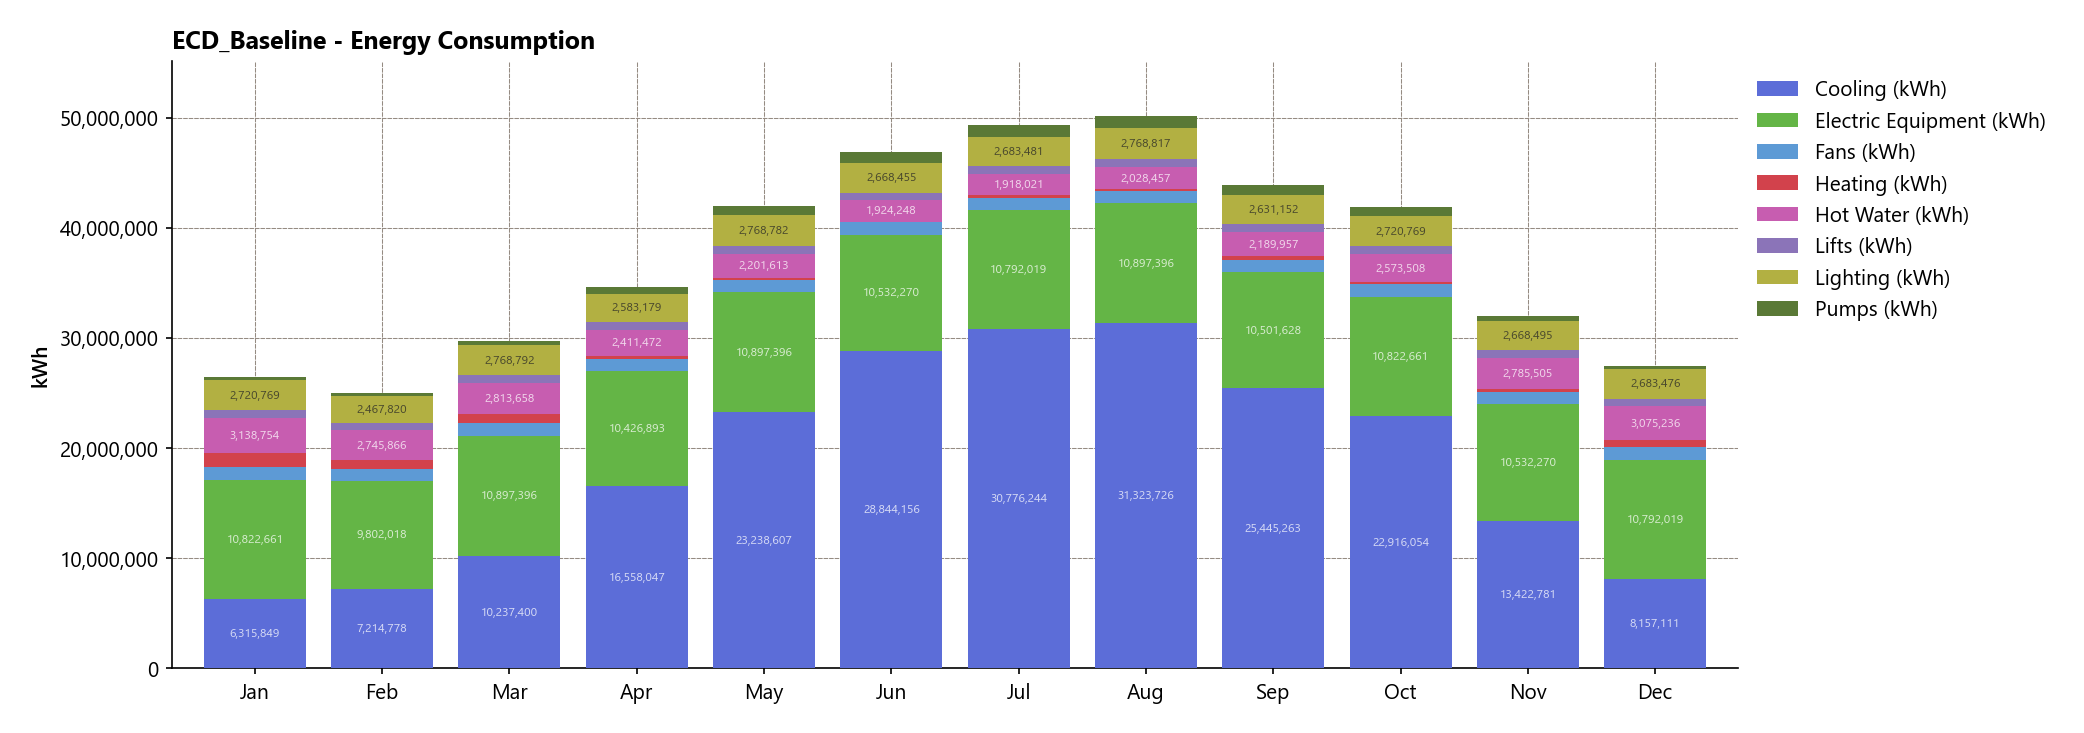

In [23]:
mped.plot_annual_monthly()


In [17]:
df.T.groupby(df.columns.get_level_values(1)).sum().T
df_norm
mped.gfa_table.values().sum()

AttributeError: 'dict_values' object has no attribute 'sum'

masterplanenergydemand - INFO - Typology(Apartments) - Reloading energy consumption


<Axes: title={'left': 'Apartments - Energy Consumption - Duration Curve'}, xlabel='kWh (per hour, Jan 00:00-Dec 23:00)', ylabel='Frequency'>

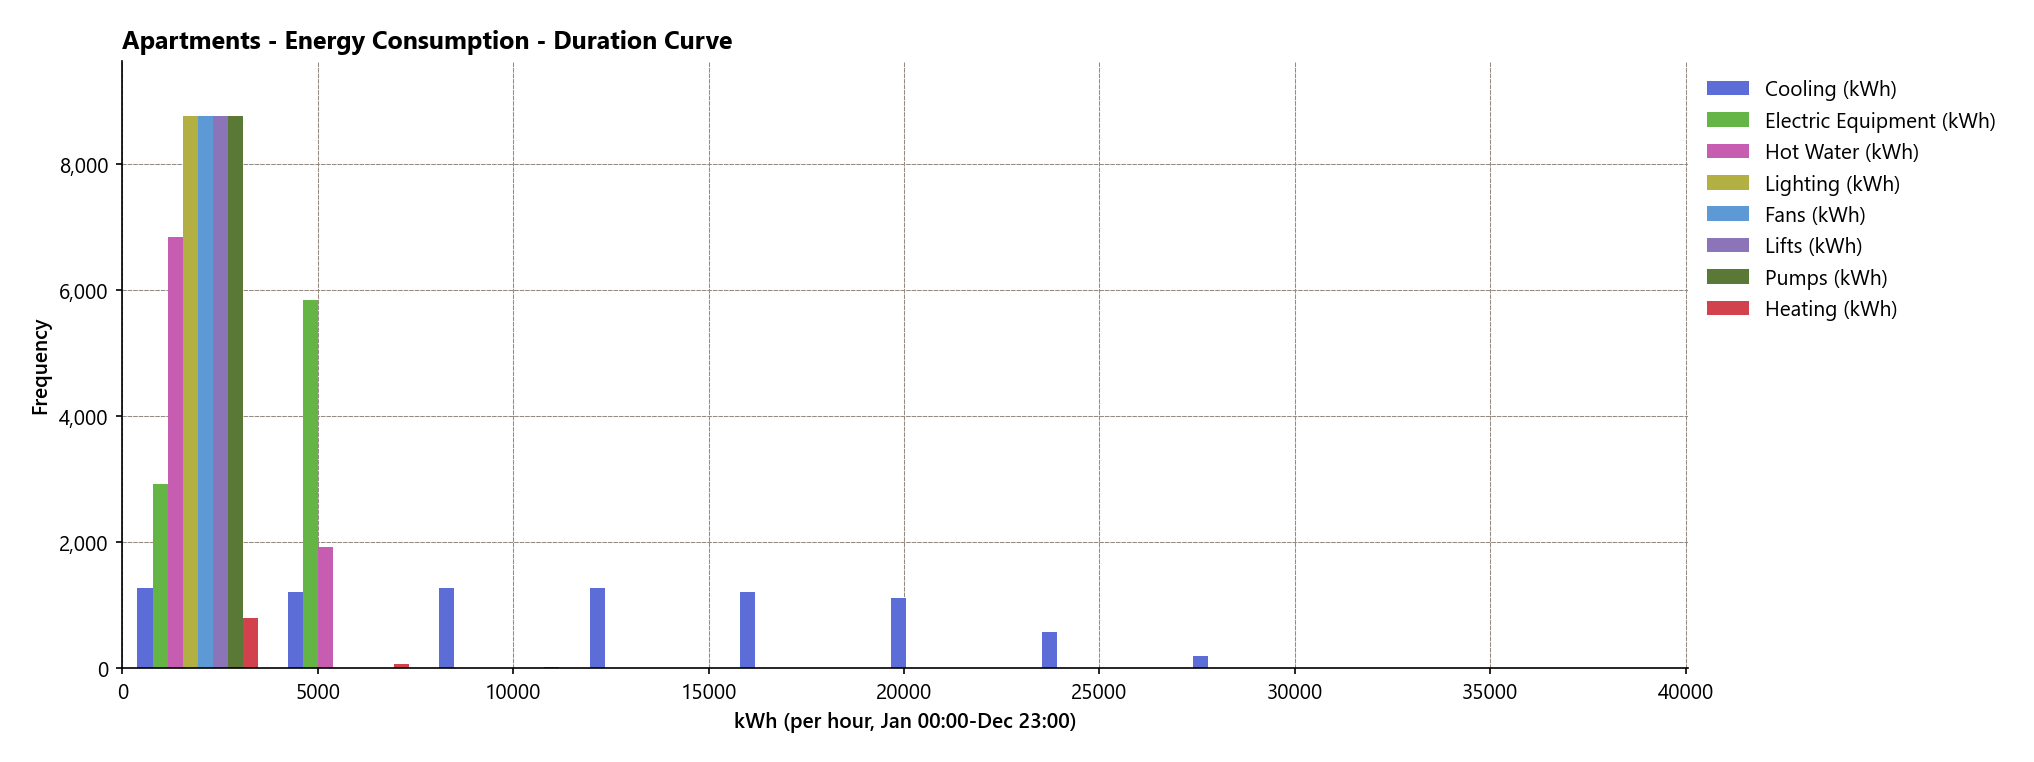

In [44]:
# mped.energy_consumption()
mped.typologies[0].plot_duration_curve(directory=mped.simulation_directory)#plot_pie_distribution()

masterplanenergydemand - INFO - Typology(PublicFacility) - Reloading energy consumption


<Axes: >

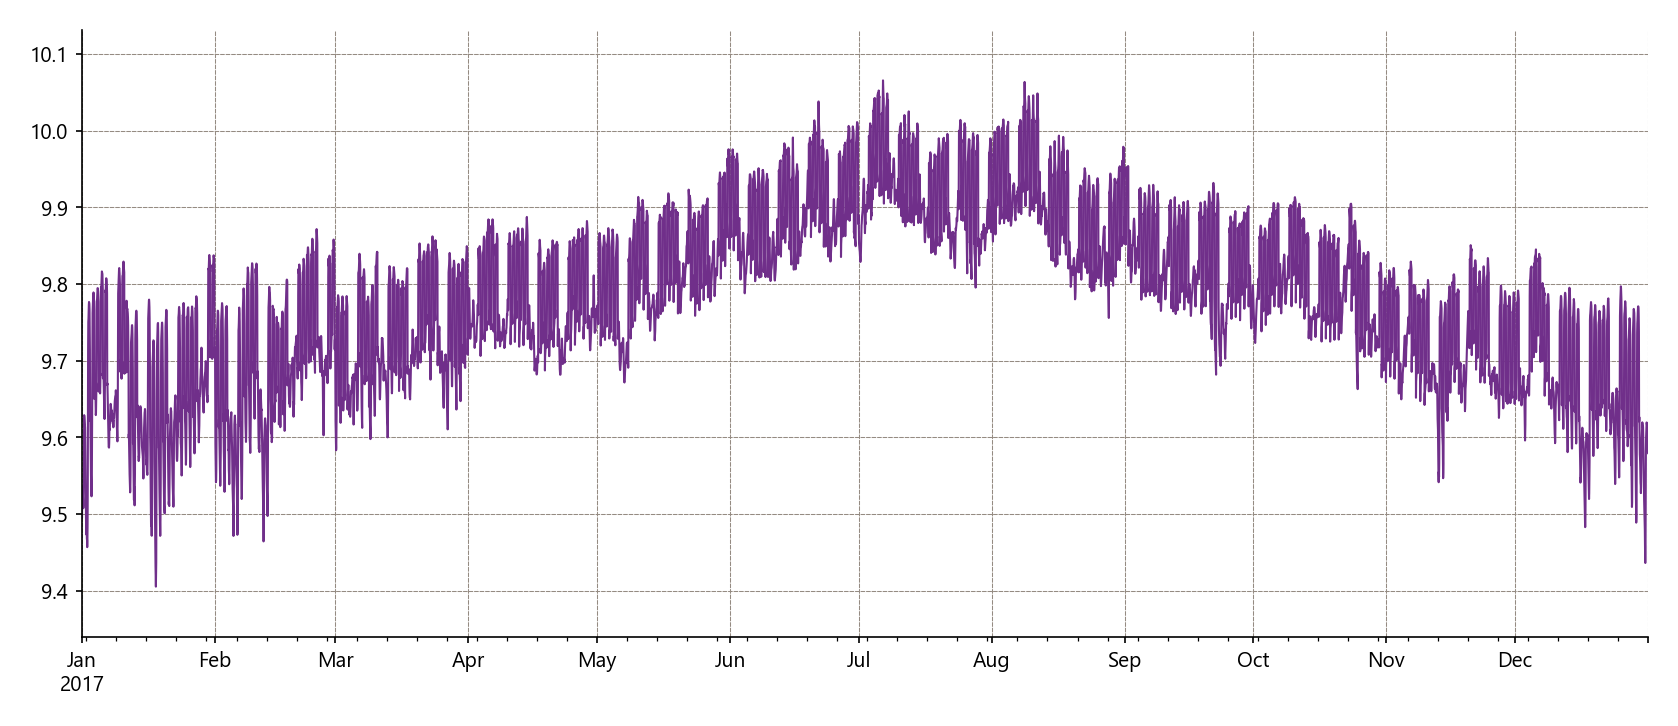

In [26]:
mped.typologies[12].energy_consumption(directory=mped.simulation_directory)["Fans (kWh)"].plot()

In [22]:
# for a given typology, use the defaults to get a model and simulate, then load into GH and try there to check for validity
total_area = 2500

epw_file = r"C:\Users\tgerrish\Buro Happold\P055843 P-Dubai Expo City Masterplan - UNS - 05_Teams Files\Sustainability and climate\Microclimate\data\ARE_DU_Dubai.World.Central.Intl.AP-Maktoum.Intl.AP.411945_TMYx.epw"
typ = Typology.from_building_type(building_type=BuildingType.HEALTHCARE_OUTPATIENT, total_area=total_area, epw_file=epw_file)
typ.average_num_floors = 5
typ.average_footprint_area = (total_area / typ.average_num_floors) / 2

# run simulation
typ._simulate()
typ._load_balance()
print(typ.basic_summary())

masterplanenergydemand - INFO - Typology - Using default identifier: Outpatient
masterplanenergydemand - INFO - Typology - Using default vintage: Vintage.ASHRAE_901_2019
masterplanenergydemand - INFO - Typology - Using default rotation: 0
masterplanenergydemand - INFO - Typology - Using default terrain: TerrainType.URBAN
masterplanenergydemand - INFO - Typology(Outpatient) - Reloading load balance data


Outpatient - BuildingType.HEALTHCARE_OUTPATIENT - Vintage.ASHRAE_901_2019
Total GFA: 2500.0 m2
Typical building GFA: 1250.0 m2
Number of buildings: 2.0
Typical storeys: 5


In [89]:
typ._lighting_energy_consumption(normalised=False, single_building=False).sum()

masterplanenergydemand - INFO - Typology(Outpatient) - Reloading lighting energy demand


62254.999999998865

masterplanenergydemand - INFO - Typology(Outpatient) - Reloading cooling energy demand
masterplanenergydemand - INFO - Typology(Outpatient) - Reloading heating energy demand
masterplanenergydemand - INFO - Typology(Outpatient) - Reloading lighting energy demand
masterplanenergydemand - INFO - Typology(Outpatient) - Reloading electric equipment energy demand
masterplanenergydemand - INFO - Typology(Outpatient) - Reloading hot water energy demand
masterplanenergydemand - INFO - Typology(Outpatient) - Calculating lifts demand
masterplanenergydemand - INFO - Typology(Outpatient) - Calculating pumps energy consumption
masterplanenergydemand - INFO - Typology(Outpatient) - Reloading load balance data
masterplanenergydemand - INFO - Typology(Outpatient) - Reloading hot water energy demand
masterplanenergydemand - INFO - Typology(Outpatient) - Reloading heating energy demand
masterplanenergydemand - INFO - Typology(Outpatient) - Reloading cooling energy demand
masterplanenergydemand - INFO - T

<Axes: title={'left': 'Outpatient - Energy Consumption\nJan 01 to Dec 31 between 00:00 and 23:59\n599MWh (over 2,500m$^2$)'}>

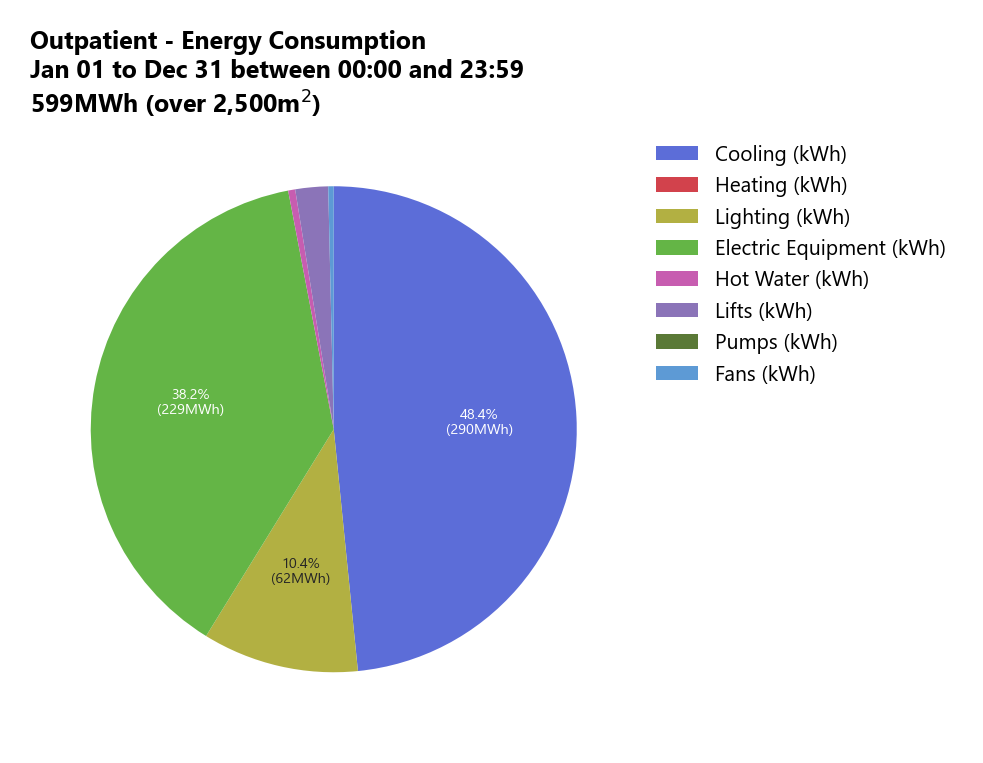

In [160]:
# run simulation and get energy consumption
# typ.energy_consumption()
# typ.plot_pie()
# (typ._hot_water_energy_consumption(normalised=False, single_building=False) * 1000).plot()
typ.plot_pie(single_building=False, analysis_period=AnalysisPeriod())
# 105kWh/m2/year resi UK

<Axes: >

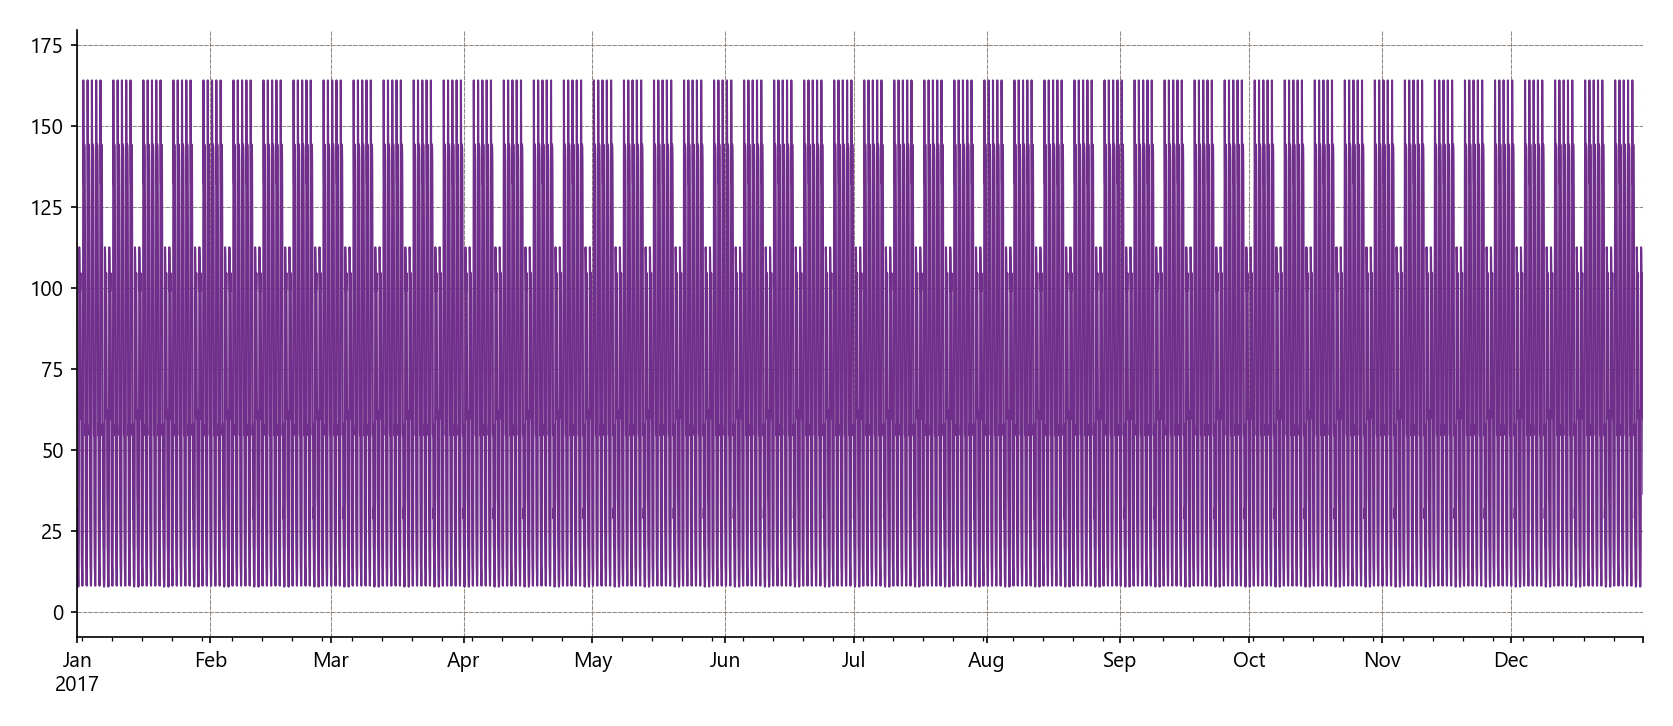

In [9]:
from masterplanenergydemand.lifts import UsageIntensity, annual_lift_usage_profile_generic, al_sharif_1996, LiftType

# get inputs
n_occupants = typ._occupants(per_building=True)
n_storeys = typ.average_num_floors
building_footprint = typ.average_footprint_area

# run calc
n_occupants, n_lifts, profile = al_sharif_1996(
    n_occupants=n_occupants, 
    n_storeys=n_storeys,
    building_footprint=building_footprint
)
profile.plot()
# do more stuff


In [72]:
usage = []
for wkday in occupancy_schedule.resample("D").mean().index.weekday:
    if wkday in [5, 6]:
        usage += usage_profile_week.weekend.values.tolist()
    else:
        usage += usage_profile_week.weekday.values.tolist()
usage = pd.Series(usage, index=occupancy_schedule.index)
usage

2017-01-01 00:00:00   0.17739332
2017-01-01 01:00:00   0.11329613
2017-01-01 02:00:00   0.10331587
2017-01-01 03:00:00   0.06088415
2017-01-01 04:00:00   0.05338822
                         ...    
2017-12-31 19:00:00   0.40859862
2017-12-31 20:00:00   0.33735175
2017-12-31 21:00:00   0.33089033
2017-12-31 22:00:00   0.34511358
2017-12-31 23:00:00   0.20142035
Length: 8760, dtype: float64

<Axes: title={'left': 'Hospital - Energy Consumption\nJan 01 to Dec 31 between 00:00 and 23:59\n49MWh'}>

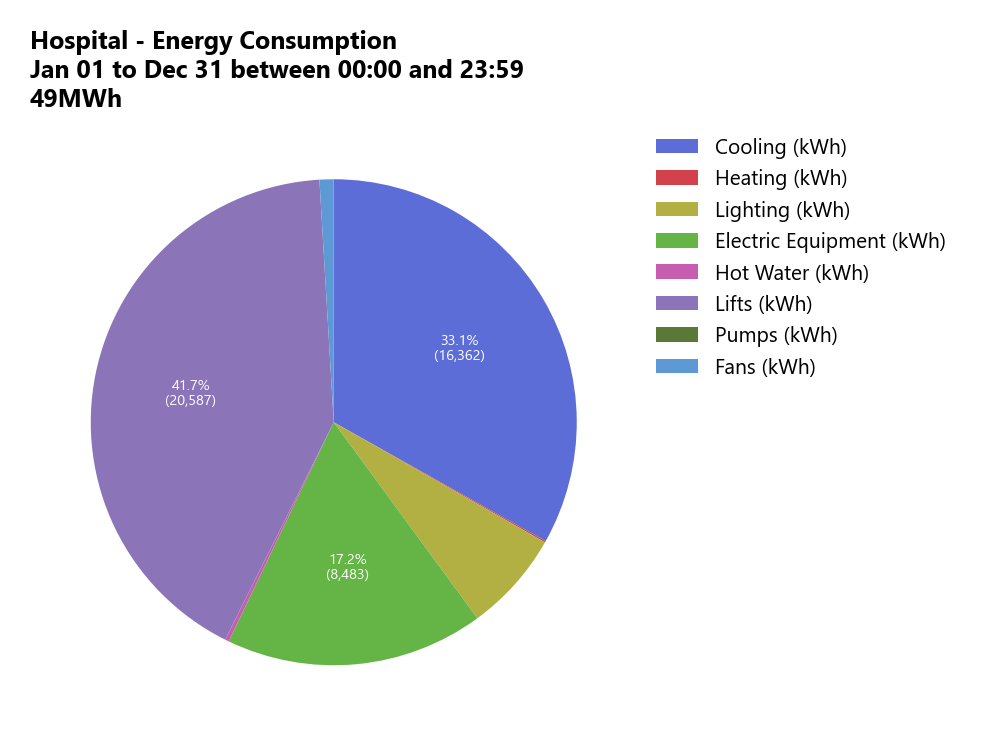

In [38]:
from masterplanenergydemand.util import room_energy_result, face_result, load_balance, collection_to_series, SQLiteResult, eui

# _sql = r"C:\Users\tgerrish\simulation\SmallDataCenterLowITE\openstudio\run\eplusout.sql"

# cooling, heating, lighting, electric_equip, gas_equip, process, hot_water, fan_electric, pump_electric, people_gain, solar_gain, infiltration_load, mech_vent_load, nat_vent_load = room_energy_result(_sql)
# face_indoor_temp, face_outdoor_temp, face_energy_flow = face_result(_sql)
# balance, balance_stor, norm_bal, norm_bal_stor = load_balance([typ._model()], cooling, heating, lighting, electric_equip, gas_equip, process, hot_water, people_gain, solar_gain, infiltration_load, mech_vent_load, nat_vent_load, face_energy_flow)

# collection_to_series(balance[6])
# typ._energy_demand().plot()#.sum() / typ.total_area
typ.plot_pie()

# sql_obj = SQLiteResult(_sql
# face_energy_flow
# eui(_sql)

<Axes: >

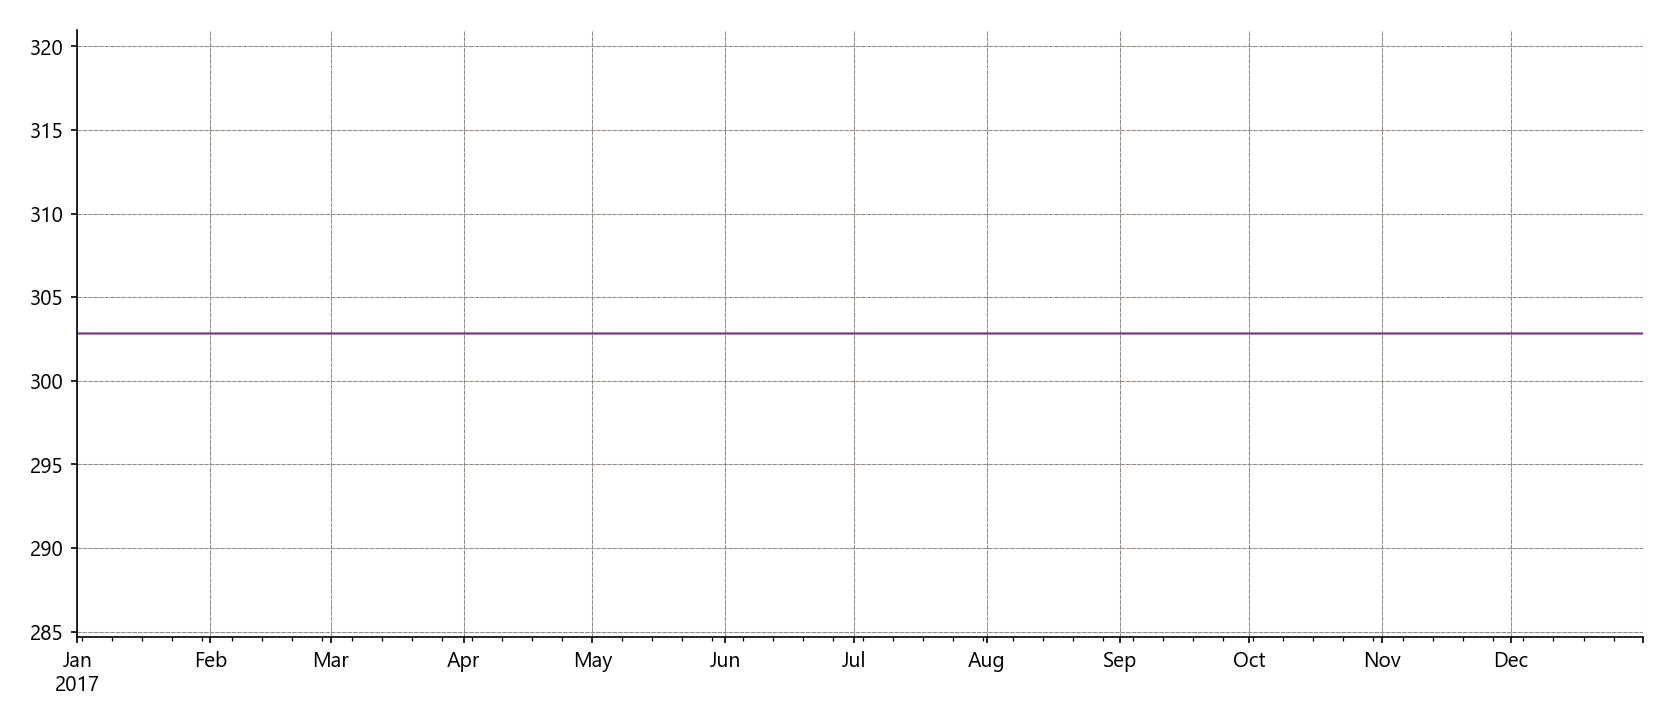

In [102]:
typ._pump_energy_consumption().plot()

In [ ]:
# mped.df()[15].head(50)
mped.typologies[15]._model().to_hbjson(folder=r"C:\Users\tgerrish\OneDrive - Buro Happold\Desktop", name="test")
mped.epw.file_path

In [ ]:
mped.plot_pie_distribution()
mped.eui(annual=True)
mped.typologies[15].eui()

In [ ]:
mped.df(extra=True).to_csv(r"C:\Users\tgerrish\Buro Happold\P055843 P-Dubai Expo City Masterplan - UNS - 05_Teams Files\Sustainability and climate\Energy\debug.csv")

In [ ]:
ind = Typology.from_building_type(total_area=10, building_type=BuildingType.INDUSTRY_LIGHT, epw_file=r"C:\Users\tgerrish\Buro Happold\P055843 P-Dubai Expo City Masterplan - UNS - 05_Teams Files\Sustainability and climate\Microclimate\data\ARE_DU_Dubai.World.Central.Intl.AP-Maktoum.Intl.AP.411945_TMYx.epw")
ind.average_footprint_area = 100
ind.average_num_floors = 1
ind.average_floor_height = 3.5
ind._simulate()

dc = Typology.from_building_type(total_area=10, building_type=BuildingType.DATACENTER_SMALL_LOW_ITE, epw_file=r"C:\Users\tgerrish\Buro Happold\P055843 P-Dubai Expo City Masterplan - UNS - 05_Teams Files\Sustainability and climate\Microclimate\data\ARE_DU_Dubai.World.Central.Intl.AP-Maktoum.Intl.AP.411945_TMYx.epw")
dc.average_footprint_area = 100
dc.average_num_floors = 1
dc.average_floor_height = 3.5
dc._simulate()


In [ ]:
import numpy as np
cmap = plt.get_cmap("cividis")
for i in np.linspace(0, 1, 11):
    x = (np.array(cmap(i))[:-1] * 255).astype(int)
    print(f"{x[0]},{x[1]},{x[2]}")

In [ ]:
import json
import subprocess 
data = json.dumps(dc._model().to_dict(), indent=4)
subprocess.run("clip", text=True, input=data)


In [ ]:
mped.df(extra=True)

In [ ]:
mped.simulate()["LightIndustry"]

In [ ]:
d = Typology.random(seed=12).dict()
d["economizer_type"] = "NoEconomizer"

Typology.from_dict(d)

In [ ]:
mped.plot_pie_distribution()

In [ ]:
# mped.typologies[5]._simulate(directory=mped.simulation_directory)

mped.typologies[6]._load_balance(directory=mped.simulation_directory).heating

In [ ]:
# [i.identifier for i in mped.typologies]


from ladybug.sql import SQLiteResult

# SQLiteResult(mped.typologies[6]._sql_file(directory=mped.simulation_directory).as_posix()).data_collections_by_output_name("Zone Electric Equipment Electricity Energy")

mped.typologies[6]._simulate(directory=mped.simulation_directory).columns

In [ ]:
for typ in mped.typologies:
    print(len(typ._simulate(directory=mped.simulation_directory).filter(regex="Load Balance Light").columns))

In [ ]:
mped.plot_pie_distribution()

In [ ]:
import numpy as np

pd.isnull("null")

In [ ]:
# mped.plot_pie()

df = mped.energy_consumption(normalise=False)
df = df.T.groupby(df.columns.get_level_values(1)).sum().T
series = df.sum(axis=0)

mped.typologies[0].estimate_lift_energy()

In [ ]:
typs = [Typology2.random() for i in range(3)]
mped = Masterplan2(identifier="hithere", typologies=typs)

target_xl = r"C:\Users\tgerrish\Downloads\a.xlsx"
edited_xl = r"C:\Users\tgerrish\Downloads\b.xlsx"
mped.to_excel(target_xl)
mped.to_excel(edited_xl)

# # reload
# Masterplan2.from_excel(excel_file=target_xl, sheet_name=mped.identifier, use_defaults=True)

# # realod from edited
# Masterplan2.from_excel(excel_file=edited_xl, sheet_name=mped.identifier, use_defaults=False)

In [ ]:
Masterplan2.from_excel(excel_file=edited_xl, sheet_name=mped.identifier, use_defaults=False)

In [ ]:
typ = Typology2.random()

typ.model()

In [ ]:
typ = Typology2.from_building_type(
    identifier="hellow", 
    building_type=BuildingType.RELIGIOUS, 
    # vintage=Vintage.ASHRAE_901_2019,
    total_area=1000, 
    epw_file=Path(r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\test.epw")
)

In [ ]:
# typ.plot_annual_monthly()
# typ.plot_pie()
# typ.plot_diurnal()
typ.plot_duration_curve(bins=100)

In [ ]:
excel_file = r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\test.xlsx"
mped = Masterplan.from_excel(excel_file=excel_file, sheet_name="TestMPED")

In [ ]:
x = mped.all_conditions()

In [ ]:
x.filter(regex="Rel").loc["2017-06"].plot()

In [ ]:
# mped.energy_consumption(normalise=False)
# mped.plot_pie_distribution()

In [ ]:
# and now for something completely different
excel_file = r"C:\Users\tgerrish\Buro Happold\P055843 P-Dubai Expo City Masterplan - UNS - 05_Teams Files\Sustainability and climate\Energy\240516_Masterplan Area Summary_per Plot.xlsx"
sheet_name = "ECD_Baseline"

mped = Masterplan.from_excel(excel_file=excel_file, sheet_name=sheet_name)

In [ ]:
mped.plot_pie_distribution()

In [ ]:
mped._data().to_clipboard(excel=True)
with pd.option_context("display.max_rows", 1000): 
    display(mped._data())


In [ ]:
# [print(i) for i in mped.typologies]

n = 4
typ = mped.typologies[n]
typ.plot_pie(epw=mped.epw, directory=mped.simulation_directory)

In [ ]:
mped.plot_pie_distribution()

In [ ]:
mped.plot_pie_distribution()

In [ ]:
n = 0
typ = mped.typologies[n]
print(typ)
print(typ.system.fan_power)
typ.plot_pie(epw=mped.epw, directory=mped.simulation_directory)
x = typ._all_data(epw=mped.epw, directory=mped.simulation_directory, single_building=False)
x[['Load Balance Mechanical Ventilation (kWh)', 'Zone Mechanical Ventilation Current Density Volume Flow Rate (m3/s)', 'Fans (kWh)']]
# mped.typologies[n].plot_pie(epw=mped.epw, directory=mped.simulation_directory)
# mped.typologies[n].simulate(epw=mped.epw, directory=mped.simulation_directory).filter(regex="Ventilation Current") / mped.typologies[n].number_of_buildings

In [ ]:
typ.occupants

program = typ.program_type
people_per_area = program.people.people_per_area
((people_per_area * typ.occupancy_schedule() * typ.total_area) / typ.number_of_buildings)

typ.program.ventilation_rate
program.ventilation.to_dict()

In [ ]:
mped.plot_pie_distribution()

In [ ]:
mped.typologies[4].simulate(epw=mped.epw, directory=mped.simulation_directory)

In [ ]:
mped.plot_pie_distribution()

In [ ]:
from honeybee.model import Model
from honeybee_energy.result.loadbalance import LoadBalance, SQLiteResult
from tqdm import tqdm

pbar = tqdm(list(Path(r"C:\Users\tgerrish\simulation\ECD_Baseline").glob("**/*.sql"))[0:1])

for sql_file in pbar:
    typ = sql_file.parents[2].name
    pbar.set_description(typ)
    model = Model.from_hbjson(hbjson_file=sql_file.parents[1] / f"{typ}.hbjson")
    lb = LoadBalance.from_sql_file(model=model, sql_path=Path(sql_file).as_posix())
    sqlr = SQLiteResult(file_path=Path(sql_file).as_posix())

In [ ]:
pd.read_csv(r"C:\Users\tgerrish\simulation\ECD_Baseline\Agriculture\results.csv", header=0, index_col=0, parse_dates=True).filter(regex="Elect").plot()

In [ ]:
cols = sqlr.data_collections_by_output_name('Zone Electric Equipment Electricity Energy')
if len(cols) == 0:
    pass
elif len(cols) == 1:
    print()
for col in :
    

In [ ]:
mped.plot_pie_distribution()

In [ ]:
n = 6
# (mped.typologies[n].sense_check(logging=False) / 1000).filter(regex="Lighting").plot()
# mped.typologies[n].profile_table()
mped.typologies[n].program.program_type(building_type=mped.typologies[n].building_type).electric_equipment

In [ ]:
mped.eui()

In [ ]:
n = 6
mped.typologies[n].energy_consumption(epw=mped.epw, directory=mped.simulation_directory).plot(title=mped.typologies[n].identifier)

In [ ]:
mped.plot_duration_curve()

In [ ]:
# logger.disabled = True
# n = 16
# _ = mped.typologies[n].profile_table().describe()
# logger.disabled = False
# print(mped.typologies[n].identifier)
# _

In [ ]:
pd.DataFrame([[typ.identifier, typ.program.occupant_density, typ.program.lighting_power_density, typ.program.equipment_power_density] for typ in mped.typologies]).set_index(0).T.to_clipboard(excel=True)
    

In [ ]:
df_all = mped.energy_consumption(total=False)

In [ ]:
df = mped.energy_consumption(total=True)

In [ ]:
temp = df_all.sum(axis=0).unstack()
temp = temp.loc[temp.sum(axis=1).sort_values(ascending=False).index]
temp

In [ ]:
# pie group
from ladybug.analysisperiod import AnalysisPeriod

ax = plt.gca()
ap = AnalysisPeriod()
legend = True

temp = mped.energy_consumption(total=False).loc[pd.to_datetime(ap.datetimes)].sum(axis=0).unstack()
temp = temp.loc[temp.sum(axis=1).sort_values(ascending=False).index]
size = 0.33
vals = temp.values
outer_colors = ["grey"]
inner_colors = [get_color(i) for i in temp.columns]
inner_wedge, _ = ax.pie(
    vals.flatten(),
    radius=1 - size,
    wedgeprops=dict(width=size, edgecolor="w", linewidth=0),
    startangle=90,
    counterclock=False,
    colors=inner_colors,
)
_, outer_txt = ax.pie(
    vals.sum(axis=1),
    radius=1,
    wedgeprops=dict(width=size, edgecolor="w", linewidth=0.5),
    startangle=90,
    counterclock=False,
    colors=["grey"],
)
for n, (name, vals) in enumerate(temp.iterrows()):
    total_prop = vals.sum() / temp.sum().sum()
    if total_prop > 0.02:
        outer_txt[n].set_text(f"{name}\n{total_prop:0.1%}")
        outer_txt[n].set_fontsize("xx-small")
if legend:
    ax.legend(
        inner_wedge[: len(temp.columns)],
        temp.columns,
        loc="upper left",
        bbox_to_anchor=(1, 1),
        ncols=1,
    )
ax.set_title(
    f"{mped.identifier}\n{ap}\n{temp.sum().sum() / 1000:,.0f}MWh"
)

In [ ]:
from masterplanenergydemand.plot import stacked_bar

# df = mped.typologies[0].energy_consumption(epw=mped.epw, directory=mped.simulation_directory)

# ax = stacked_bar(
#     df
# )
# ax.set_title("abc")

df = mped.typologies[2].plot_duration_curve(epw=mped.epw, directory=mped.simulation_directory, remove_zero=True, histtype="barstacked", cumulative=-1, bins=100, density=False)

In [ ]:
ax = plt.gca()

data = df[df.sum(axis=0).sort_values(ascending=False).index]

ax.hist(data, bins=100)

In [ ]:
from masterplanenergydemand.config import logger

logger.disabled = True

n = 16
print(mped.typologies[n])
print(mped.typologies[n].sense_check().filter(regex="\(W\)").sum() / 1000)

logger.disabled = False

In [ ]:
from masterplanenergydemand.config import logger

logger.disabled = True

n = 13
print(mped.typologies[n])
print(mped.typologies[n].sense_check().filter(regex="\(W\)").sum() / 1000)

logger.disabled = False

In [ ]:
df = mped.energy_consumption(total=False)

In [ ]:
df.filter(regex="Electric").sum()#.sum(axis=0).unstack().plot(kind="bar", stacked=True)

In [ ]:
n = 18
print(mped.typologies[n])
mped.typologies[n].energy_consumption(epw=mped.epw, directory=mped.simulation_directory).resample("MS").sum().plot(kind="bar", stacked=True)

In [ ]:
mped.energy_consumption(total=True).resample("MS").sum().plot(kind="bar", stacked=True)

In [ ]:
df_ec.filter(regex="Lifts").loc["2017-06"].sum().droplevel(1) / pd.Series(mped.gfa_table)

In [ ]:
# NOTES - check the EUI for each typology - create a method which does this fo the year to sense check things against a common metric!
# Chekc the occupant dnesity for the accomodation typologies


In [ ]:
df_res.filter(regex="Water Use Equipment Zone Sensible Heat Gain Energy Intensity")
df_res.filter(regex="Service Hot Water").plot()

In [ ]:
for i in range(12):
    a = pd.concat([
        df.filter(regex="Hot Water").filter(regex="calc").iloc[:, i],
        df.filter(regex="Hot Water").filter(regex="eplus").iloc[:, i],
    ], axis=1).sum()
    print(a)

In [ ]:
x = mped.population().sum(axis=1)
# x.groupby(x.index.hour).mean().plot()
x.plot()

In [ ]:
building_type = BuildingType.ACCOMODATION_APARTMENT_HIGHRISE
vintage = Vintage.ASHRAE_901_2004

# get property
ashrae_climate = int(epw.ashrae_climate_zone[0])
from masterplanenergydemand.enums import EconomizerType
list(EconomizerType)
EconomizerType[df[(df.building_type == building_type.name) & (df.vintage == vintage.name) & (df.ashrae_climate == ashrae_climate)].economizer_type.values[0]]

In [ ]:
# test from building type

bt = BuildingType.COMMERCIAL_OFFICE_LARGE

# x = Fabric.from_building_type(bt, epw=epw, vintage=Vintage.ASHRAE_901_2007)
# x.constructions()

# x = Form.from_building_type(bt)
# x.base_model()

x = 

In [ ]:
# run the test excel file to debug and generate results
mped = Masterplan.from_excel(excel_file, "TestMPED")

In [ ]:
# create some typologies to start summarising, and sense checking

Typology(
    identifier="Test1",
    building_type=BuildingType.CIVIC_COURTHOUSE, 
    total_area=1000, 
    vintage=Vintage.ASHRAE_901_2019,
    fabric=Fabric(
        wall_u_value=[1] * 8,
        wall_sri=55,
        floor_u_value=0.5,
        roof_u_value=0.75,
        window_u_value=[0.99] * 8,
        window_shgc=[0.5] * 8,
        skylight_u_value=0.99,
        skylight_shgc=0.3,
        roof_sri=60,
    ), 
    form=Form(
        average_footprint_area=100,
        average_num_floors=2,
        average_floor_height=3.5,
        rotation=0,
        terrain=TerrainType.URBAN,
        glazing_ratio=[0.25, 0.1, 0.25, 0.4, 0.3, 0.2, 0.1, 0],
        skylight_ratio=0.0,
    ), 
    program=Program.from_building_type(building_type=BuildingType.COMMERCIAL_OFFICE_LARGE, 
    system=System(), 
)

In [ ]:
Masterplan.random(seed=1) == Masterplan.random()

# mped.simulation_directory
# df = mped.results()

In [ ]:
import numpy as np

length  = 8
alpha_num = list('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')
np_codes = "".join(np.random.choice(alpha_num, size=length))
np_codes


In [ ]:
typ_0, typ_1 = df.iloc[:, df.columns.get_level_values(1) == "People (kWh)"].mean().values

# df.columns.get_level_values(1) == "People (kWh)"

In [ ]:
df = mped.energy_consumption()
# df = mped.results()

In [ ]:
df

In [ ]:
df.filter(regex="Water").sum()#.plot()

In [ ]:
typologies = [Typology.random() for i in range(2)]

In [ ]:
df = pd.read_excel(excel_file, sheet_name="INPUTS", engine="openpyxl", header=None, index_col=0)

In [ ]:
d = df[3].to_dict()
# Typology.parse_obj_extended(d)
Program.parse_obj(d)

In [ ]:
for v in Vintage:
    print(v, v.name, v.value)

In [ ]:
typologies[0].json()

In [ ]:
Masterplan(identifier="test", epw_file=epw_file, typologies=typologies).json()

In [ ]:
pd.read_excel(r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\inputs.xlsx", sheet_name="INPUTS", engine="openpyxl", header=None, index_col=0).loc[:, 2]['epw_file']

In [ ]:
Masterplan.from_excel(
    excel_file=r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\inputs.xlsx",
    sheet_name="INPUTS"
)

In [ ]:
for bt in EconomizerType:
    print(bt.value)

In [ ]:
from IPython.display import JSON

JSON(Masterplan(identifier="test", epw_file=epw_file, typologies=typologies).json())

In [ ]:
Fabric.random().dict()

# # d = {
# #     'average_footprint_area': 100,
# #     'average_num_floors': 1,
# #     'average_floor_height': 3.5,
# #     'rotation': 0,
# #     'terrain': TerrainType.URBAN,
# #     'glazing_ratio': [0.5] * 8,
# #     'skylight_ratio': 0
# # }
d = {
    "wall_u_value_N": 0.5,
    "wall_u_value_NE": 0.5,
    "wall_u_value_E": 0.5,
    "wall_u_value_SE": 0.225,
    "wall_u_value_S": 0.5,
    "wall_u_value_SW": 0.5,
    "wall_u_value_W": 0.5,
    "wall_u_value_NW": 0.5,
    'wall_sri': 20.053532030901586,
    'floor_u_value': 2.2087810041663256,
    'roof_u_value': 3.489979042863111,
    'window_u_value': [
        5.061284967811305,
        3.9383370420013306,
        5.034827553969595,
        0.4212017612451234,
        0.7279954371015188,
        4.3533948173007735,
        0.7809723588597011,
        1.6127795480690812
    ],
    "window_shgc": 0.44,
    "window_shgc_N": 0.44,
    "window_shgc_NE": 0.44,
    "window_shgc_E": 0.44,
    "window_shgc_SE": 0.44,
    "window_shgc_S": 0.44,
    "window_shgc_SW": 0.44,
    "window_shgc_W": 0.44,
    "window_shgc_NW": 0.44,
    'skylight_u_value': 4.566658066906907,
    'skylight_shgc': 0.7448610188775975,
    'roof_sri': 15.608411640628798
}
Fabric.parse_obj_extended(d).window_shgc

In [ ]:
# typologies[0].program.profile_table(typologies[0].building_type).filter(regex="Hot Water").plot()
aa = []
for _ in range(10):
    typ = Typology.random()
    aa.append(typ.program.profile_table(typ.building_type).filter(regex="Hot Water").squeeze().rename(typ.building_type.name))
pd.concat(aa, axis=1).plot()

In [ ]:
typologies[0].gain_people(normalised=True).plot(legend=True)

In [ ]:
mp = Masterplan(
    identifier="hi",
    typologies=typologies,
    epw_file=epw_file
)
results = mp.simulate()

In [ ]:
results.columns.get_level_values(1).unique()

In [ ]:
Program(building_type="BuildingType.COMMERCIAL_OFFICE_MEDIUM").dict()

In [ ]:
df = Typology(identifier="Office").results(
    epw=EPW(r"C:\Users\tgerrish\Documents\GitHub\BHoM\LadyBugTools_Prototypes\LadyBugTools_Prototype_Engine\Python\MasterplanEnergyDemand\masterplanenergydemand\test\test.epw"),
    save=True
)
df.head()

In [ ]:
df

In [ ]:
# mped.system.System()
# mped.fabric.Fabric()
# mped.form.Form()
# mped.program.Program()

In [ ]:
mped.enums

In [ ]:

json_str = mped.program.Program().json()
mped.program.Program.parse_raw(json_str)

mped.program.Program().get_program(mped.enums.BuildingType.EDUCATION_COLLEGE)

In [ ]:
# frm = mped.TypologyForm(
#     average_footprint_area=100, 
#     average_num_floors=12, 
#     glazing_ratio=[0.1, 0.4, 0, 0, 0, 0, 0, 0], 
#     rotation=0, 
#     terrain=mped.form.TerrainType.OCEAN, 
#     skylight_ratio=0.0
# ).base_model().to_hbjson()

frm = mped.TypologyForm.from_defaults(mped.form.BuildingType.ACCOMODATION_HOTEL_LARGE)
# mped.TypologyForm()
# frm.base_model()
# mped.enums.default_context_shade_distance(mped.TerrainType.CITY)

In [ ]:
mped.fabric.Fabric()

In [ ]:
from typing import Any

def number_validator(value: float | int, prop_name: str, gt: float = None, ge: float = None, lt: float = None, le: float = None) -> None:
    if not isinstance(value, (float, int)):
        raise ValueError(f"{prop_name} must be a number")
    if gt is not None and ge is not None:
        raise ValueError("Both 'gt' and 'ge' cannot be provided.")
    if lt is not None and le is not None:
        raise ValueError("Both 'lt' and 'le' cannot be provided.")
    if gt is not None and value <= gt:
        raise ValueError(f"{prop_name} must be greater than {gt}")
    if ge is not None and value < ge:
        raise ValueError(f"{prop_name} must be greater than or equal to {ge}")
    if lt is not None and value >= lt:
        raise ValueError(f"{prop_name} must be less than {lt}")
    if le is not None and value > le:
        raise ValueError(f"{prop_name} must be less than or equal to {le}")

def list_of_nums_validator(value: Any, prop_name: str, length: int, ge: float = None, le: float = None, gt: float = None, lt: float = None) -> None:
    if not isinstance(value, (list, tuple)):
        raise ValueError(f"{prop_name} must be a list or tuple")
    if len(value) != length:
        raise ValueError(f"{prop_name} must have {length} items")
    for i in value:
        number_validator(i, prop_name, gt, ge, lt, le)


list_of_nums_validator([0, 1, 2, 3, 11], "XYZ", length=5, ge=0, lt=11.99)


In [ ]:
for building_type in BuildingType:
    print(building_type, default_construction_type(building_type))

In [ ]:


# from masterplanenergydemand.mped import *
# from masterplanenergydemand.utilities import *
# from masterplanenergydemand.programs.ncm import load_access_tables

In [ ]:
from ladybug.climatezone import ashrae_climate_zone, HourlyContinuousCollection

xx = []
heating_cops = []
cooling_eers = []
fan_powers = []
pump_powers = []
sens_hres = []
lat_hres = []
for bt in BuildingType:
    for v in Vintage:
        for clim in range(8):
            clim += 1
            xx.append([bt.name, v.name, clim])
            
            # get the cooling eer by interpolating between min/max
            cooling_eers.append(np.interp((vintage_val_map[v.name]) * (climate_val_map[clim]), [0, 1], [2.5, 10]))

            # get the heating cop by interpolating between min/max
            heating_cops.append(np.interp((vintage_val_map[v.name]) * (1 - climate_val_map[clim]), [0, 1], [1, 4]))

            # get fan power mapping, 
            fan_powers.append(np.interp((1 - vintage_val_map[v.name]) * (fp_map[bt.name]), [0, 1], [1.2, 2.5]))

            # get HR effectivenes
            sens_hres.append(np.interp((vintage_val_map[v.name]), [0, 1], [0, 0.4]))
            lat_hres.append(np.interp((vintage_val_map[v.name]), [0, 1], [0, 0.2]))
            
rr = pd.concat([
    pd.DataFrame(xx), 
    pd.Series(cooling_eers, name="cooling_eer"), 
    pd.Series(heating_cops, name="heating_cop"), 
    pd.Series(fan_powers, name="fan_power"), 
    pd.Series([0.35] * len(xx), name="pump_power"), 
    pd.Series(sens_hres, name="sensible_heat_recovery_effectiveness"),
    pd.Series(lat_hres, name="latent_heat_recovery_effectiveness")
], axis=1)
# rr["fan_power"].groupby([rr[0], rr[1]]).mean().unstack()
# rr

rr[["cooling_eer", "heating_cop", "fan_power", "pump_power", "sensible_heat_recovery_effectiveness", "latent_heat_recovery_effectiveness"]].to_clipboard(excel=True)
rr